# XGBoost v2 (Flights + Weather)

This notebook builds on v1 by:

1. Adding weather features (tmpf, vsby, sknt, p01i, relh, gust)
2. Adding cyclical time encodings for month, day of week, and hour
3. Keeping everything else identical to v1 (same parameters)

The goal is to see if weather features alone can beat baseline performance

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import sys
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [5]:
sys.path.append('../../../4_scripts')
from flight_weather_setup import load_data, FEATURES

df = load_data()
features = [f for f in FEATURES if f in df.columns]

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

X_train, y_train = train[features], train['target'].astype(int)
X_val,   y_val   = val[features],   val['target'].astype(int)
X_test,  y_test  = test[features],  test['target'].astype(int)

if len(X_train) > 2_000_000:
    idx = np.random.choice(len(X_train), 2_000_000, replace=False)
    X_train = X_train.iloc[idx]
    y_train = y_train.iloc[idx]

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')
print(f'features ({len(features)}): {features}')

train: (13777101, 18), val: (6310951, 18), test: (4077639, 18)
features (18): ['Airline', 'Origin', 'Month', 'DayOfWeek', 'dep_hour', 'Distance', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']


In [6]:
print(f'total features: {len(features)}')
print(features)

total features: 18
['Airline', 'Origin', 'Month', 'DayOfWeek', 'dep_hour', 'Distance', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']


In [19]:
# cap training set for faster iteration
if len(X_train) > 2_000_000:
    idx = np.random.choice(len(X_train), 2_000_000, replace=False)
    X_train = X_train.iloc[idx]
    y_train = y_train[idx]
    print(f'training capped to {len(X_train):,} rows')

## Training

Same baseline params as v1, keeping everything identical except the features. That way any improvement we see is directly from adding weather data.

In [9]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_class=3, ...)


val macro F1: 0.3267
              precision    recall  f1-score   support

     on_time       0.82      0.99      0.90   5127027
     delayed       0.49      0.03      0.06   1072910
   cancelled       0.46      0.01      0.03    111014

    accuracy                           0.81   6310951
   macro avg       0.59      0.35      0.33   6310951
weighted avg       0.76      0.81      0.74   6310951



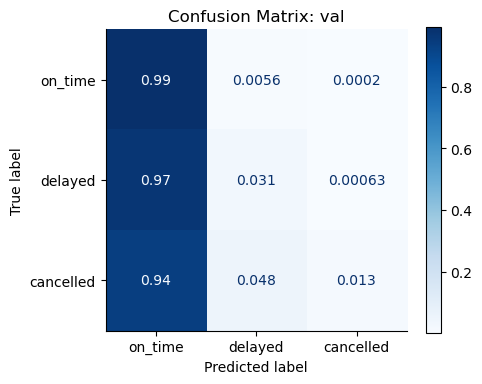

In [16]:
def evaluate(model, X, y_true, label='val'):
    y_pred = model.predict(X)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n{label} macro F1: {mf1:.4f}')
    print(classification_report(y_true, y_pred,
          target_names=['on_time','delayed','cancelled'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(5,4))
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=['on_time','delayed','cancelled'])
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {label}')
    plt.tight_layout()
    plt.show()
    return mf1
mf1_val = evaluate(model, X_val, y_val, 'val')

## Val Results

## Weather Feature Importance

Highlighting weather features in red to see how much they contribute vs the baseline flight features.

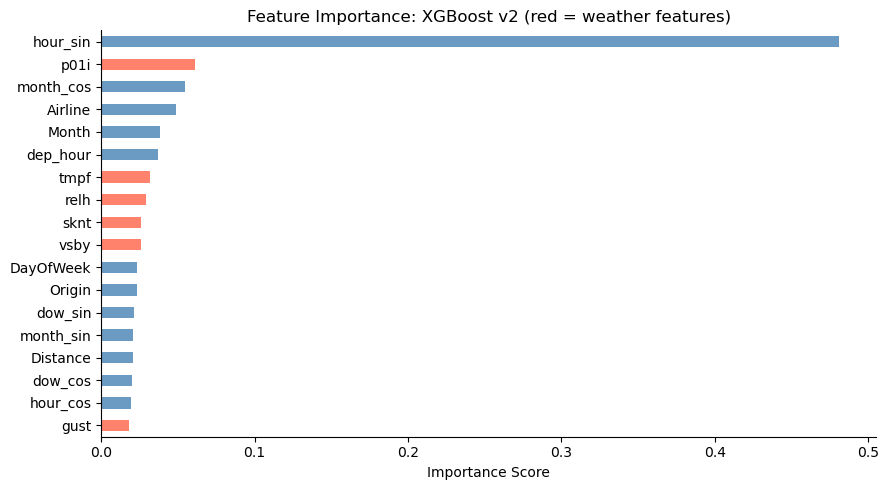

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
colors = ['tomato' if f in ['tmpf','vsby','sknt','p01i','relh','gust'] else 'steelblue'
          for f in importance.index]
importance.plot(kind='barh', color=colors, alpha=0.8, ax=ax)
ax.set_title('Feature Importance: XGBoost v2 (red = weather features)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Test Set Results


test macro F1: 0.3179
              precision    recall  f1-score   support

     on_time       0.76      0.99      0.86   3091391
     delayed       0.49      0.03      0.05    863057
   cancelled       0.55      0.02      0.04    123191

    accuracy                           0.76   4077639
   macro avg       0.60      0.35      0.32   4077639
weighted avg       0.70      0.76      0.67   4077639



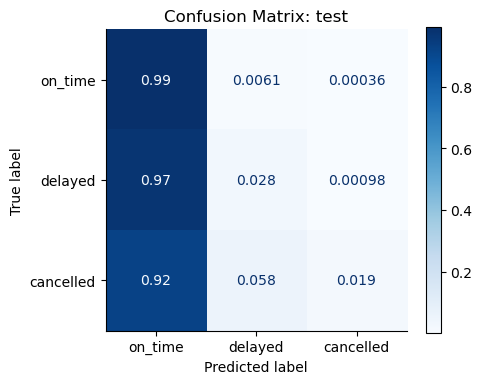

In [18]:
mf1_test = evaluate(model, X_test, y_test, 'test')

## v1 vs v2 Comparison

Does adding weather actually help?

                 model  features  val macro F1  test macro F1
     v1 (flights only)         6        0.3054         0.2954
v2 (flights + weather)        18        0.3267         0.3179


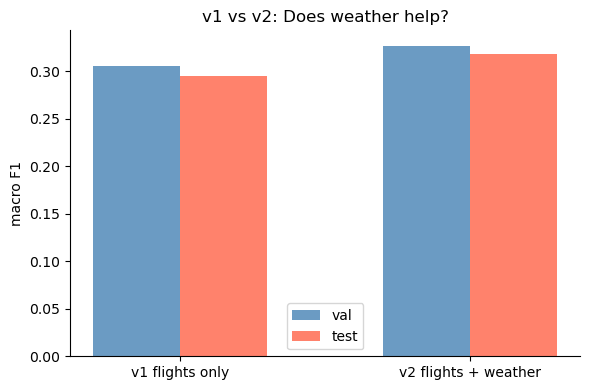

In [20]:
# v1 baseline results
v1_val  = 0.3054
v1_test = 0.2954

comparison = pd.DataFrame({
    'model':         ['v1 (flights only)', 'v2 (flights + weather)'],
    'features':      [6, 18],
    'val macro F1':  [v1_val,  round(mf1_val,  4)],
    'test macro F1': [v1_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
width = 0.3
ax.bar(x - width/2, [v1_val,   mf1_val],  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, [v1_test,  mf1_test], width, label='test', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['v1 flights only', 'v2 flights + weather'])
ax.set_ylabel('macro F1')
ax.set_title('v1 vs v2: Does weather help?')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Adding weather features and cyclical time encodings on top of the same baseline params. If macro F1 goes up, it means the weather data is actually useful. If cancelled recall is still 0%, then more features alone won't fix the imbalance problem, so our next plan is to resample the data.

In [25]:
import joblib
import os
os.makedirs('/home/t1sanchez/capstone/modelos', exist_ok=True)
joblib.dump(model, '/home/t1sanchez/capstone/modelos/model_v2.pkl')
print('model saved')


model saved
